
## Regressão Linear Simples

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style()

df = pd.read_csv("http://dl.dropboxusercontent.com/s/g8cgvjiorjbz54p/precificacao_housing.csv?dl=0")

df.head()

,GrLivArea,SalePrice
0,1710,208500
1,1262,181500
2,1786,223500
3,1717,140000
4,2198,250000


O *dataset* importado contém a variável `GrLivArea` contendo o tamanho do imóvel ($m^2$) e a variável alvo `SalePrice` com o preço de venda do mesmo. Vou plotar um gráfico de dispersão para termos ideia de como os pontos estão relacionados.


###Gráfico de dispersão

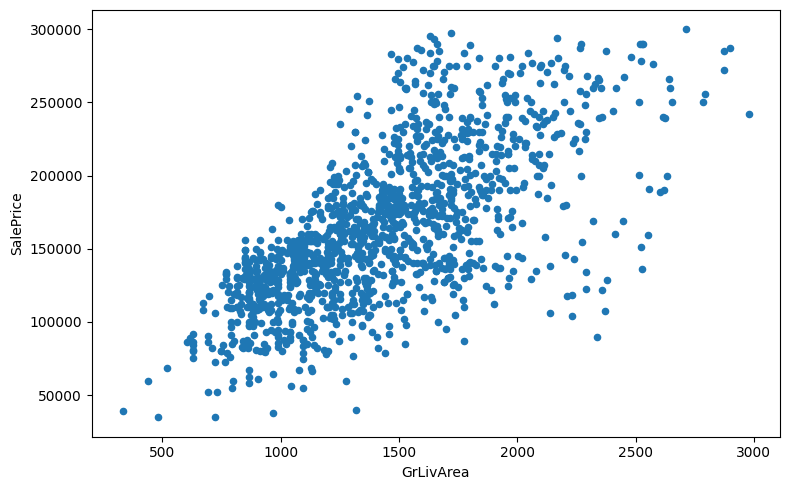

In [3]:
fig,ax = plt.subplots(figsize = (8,5))
df.plot.scatter(x='GrLivArea', y='SalePrice', ax=ax)
plt.tight_layout()


### Regressão Linear Simples com o `scikit-learn`

Dividindo o meu conjunto de dadtos entre *train* e *test* para que sejam mutuamente exclusivos. Será dividido 20% dos dados do *dataset* para o teste final.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [5]:
X = df['GrLivArea'].values.reshape(-1,1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y)

rls_model = LinearRegression()
rls_model.fit(X_train, y_train)

LinearRegression()

Para obter o coeficiente de regressão e intercepto, acesso diretamente a variável `ml_model`

In [6]:
print("Coeficiente:\t", rls_model.coef_)
print("Intercepto:\t", rls_model.intercept_)


Coeficiente:	 [83.4828187]
Intercepto:	 43924.28155749838




O que quer dizer que para cada 1 m2 a mais da área do imóvel, o modelo estimou um acréscimo de 83,48$.



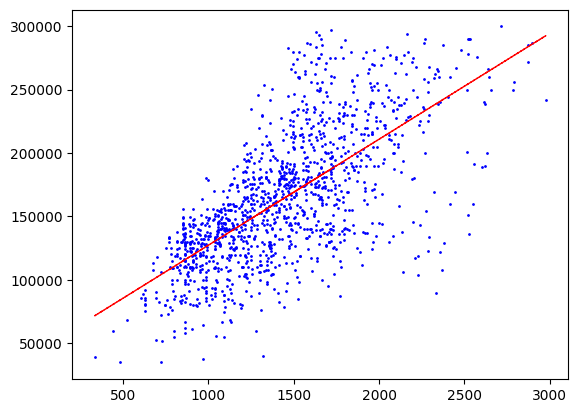

In [7]:
fig, ax = plt.subplots()
ax.scatter(X, y, s=1, color='blue')
ax.plot(X, (rls_model.coef_ * X + rls_model.intercept_), '--r', linewidth=1)

In [8]:
y_pred = rls_model.predict(X_test)

y_pred

array([230007.48443498, 174741.85845701, 127323.61743664, 218152.92417989,
       163638.6435702 , 181420.48395284, 125737.44388138, 166644.02504332,
       166477.05940593, 232845.90027071, 155540.81015651, 131581.24119023,
       177830.72274883, 215397.99116286, 167812.78450509, 124735.65005701,
       152618.91150208, 174491.41000092, 230090.96725368, 154038.11941995,
       110960.98497186, 142100.07634616, 148444.77056719, 119643.19811644,
       179249.93066669, 149780.49566636, 120060.61220993, 257139.40051178,
       175409.72100659, 157711.36344265, 121062.4060343 , 193525.49266403,
       117556.12764899,  87335.34728037, 163805.60920759, 208385.43439224,
       197449.18514282, 170818.16597821, 162135.95283364, 203543.43090777,
       156125.18988739, 227586.48269274, 155791.2586126 , 125737.44388138,
       159214.05417921, 199285.80715418, 179667.34476018, 112046.26161493,
       194193.35521361, 114717.71181327, 181337.00113414, 118557.92147337,
       180836.10422195, 1

In [17]:
comparacao = pd.DataFrame({
    'Valor Real': y_test.values,
    'Previsão Modelo': y_pred.round(2)
})

comparacao.head()

,Valor Real,Previsão Modelo
0,164700,167019.34
1,98000,87585.94
2,137000,147649.76
3,149000,153407.92
4,204000,206561.58


para o imóvel 0 o valor atual dele é de 164.700 mil dólares, mas o valor que o modelo previu deveria ser um pouco acima disso custando 167.019,34 mil dólares

Ele superestimou o preço em 2.319,34

In [18]:
comparacao['Erro'] = comparacao['Previsão Modelo'] - comparacao['Valor Real']

comparacao['Erro Percentual (%)'] = (
    comparacao['Erro'].abs() / comparacao['Valor Real'] * 100
).round(2)

comparacao.head()

,Valor Real,Previsão Modelo,Erro,Erro Percentual (%)
0,164700,167019.34,2319.34,1.41
1,98000,87585.94,-10414.06,10.63
2,137000,147649.76,10649.76,7.77
3,149000,153407.92,4407.92,2.96
4,204000,206561.58,2561.58,1.26


In [9]:
print("R2 Score:\t", r2_score(y_test, y_pred))
print("MAE:\t\t", mean_absolute_error(y_test, y_pred))
print("MSE:\t\t", mean_squared_error(y_test, y_pred))

R2 Score:	 0.4083250437117659
MAE:		 30501.786512258794
MSE:		 1666371769.405517


## Regressão Linear Múltipla

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

sns.set_style()

df2 = pd.read_csv("http://dl.dropboxusercontent.com/s/gc1rm540g4i670n/precificacao_housing_plus.csv?dl=0")

print("Tamanho de df2: {}\n".format(df2.shape))

df2.drop('Id', axis=1, inplace=True)
df2.head()

Tamanho de df2: (1460, 35)



,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,8450,7,5,2003,2003,706,0,150,856,...,0,61,0,0,0,0,0,2,2008,208500
1,20,9600,6,8,1976,1976,978,0,284,1262,...,298,0,0,0,0,0,0,5,2007,181500
2,60,11250,7,5,2001,2002,486,0,434,920,...,0,42,0,0,0,0,0,9,2008,223500
3,70,9550,7,5,1915,1970,216,0,540,756,...,0,35,272,0,0,0,0,2,2006,140000
4,60,14260,8,5,2000,2000,655,0,490,1145,...,192,84,0,0,0,0,0,12,2008,250000


In [15]:
X = df2.drop('SalePrice', axis=1)
y = df2['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y)

rlm_model = LinearRegression()
rlm_model.fit(X_train, y_train)

LinearRegression()

In [12]:
print("df:\t\t",df2.shape)

print("X:\t\t",X.shape)

print("y:\t\t", y.shape)

df:		 (1460, 34)
X:		 (1460, 33)
y:		 (1460,)


In [16]:
y_pred = rlm_model.predict(X_test)

print("R2 Score:\t", r2_score(y_test, y_pred))
print("MAE:\t\t", mean_absolute_error(y_test, y_pred))
print("MSE:\t\t", mean_squared_error(y_test, y_pred))

R2 Score:	 0.8103083641763864
MAE:		 22584.282759173788
MSE:		 1386503649.2318985
